# Monthly Salary Prediction

This notebook builds and evaluates regression models that predict the midpoint
of an advertised monthly salary range in PLN.

## 1. Problem Definition

The target variable is `salary_mid_pln_monthly`. The analysis asks which
job-offer characteristics are most useful for predicting advertised salary.

The model is intended to describe salary patterns in the collected offers. It
does not estimate the market value of an individual candidate.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

## 2. Modeling Dataset

Only offers marked as eligible for salary analysis are included. During data
preparation, normalized salary midpoints below PLN 5,000 or above PLN 100,000
were retained in the source dataset but excluded from salary analysis.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "nofluff_it_jobs_clean.csv"
df = pd.read_csv(DATA_PATH)
model_df = df.loc[df["salary_analysis_eligible"]].copy()

print(f"All offers: {len(df):,}")
print(f"Modeling observations: {len(model_df):,}")
model_df["salary_mid_pln_monthly"].describe().round(2)

All offers: 3,360
Modeling observations: 2,339


count     2339.00
mean     24703.59
std       7331.91
min       5000.00
25%      20160.00
50%      24360.00
75%      29030.00
max      81900.00
Name: salary_mid_pln_monthly, dtype: float64

In [3]:
assert model_df["salary_mid_pln_monthly"].notna().all()
assert model_df["salary_mid_pln_monthly"].between(5_000, 100_000).all()
assert model_df["job_id"].is_unique

## 3. Feature Selection and Train-Test Split

The initial feature set contains structured job attributes. Salary source
columns are deliberately excluded to prevent target leakage. The test set is
held back and used only once, after model selection and tuning.

In [4]:
target = "salary_mid_pln_monthly"
categorical_features = [
    "experience",
    "category",
    "contract_type",
    "workplace",
    "job_locations",
    "company_size_segment",
]
numeric_features = ["experience_years_min"]
feature_columns = categorical_features + numeric_features

X = model_df[feature_columns].copy()
y = model_df[target].copy()

feature_quality = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "missing_pct": (X.isna().mean() * 100).round(1),
    "unique_values": X.nunique(dropna=True),
})
feature_quality

,dtype,missing,missing_pct,unique_values
experience,object,0,0.0,4
category,object,0,0.0,31
contract_type,object,365,15.6,4
workplace,object,150,6.4,2
job_locations,object,0,0.0,17
company_size_segment,object,0,0.0,5
experience_years_min,float64,1035,44.2,11


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

assert set(X_train.index).isdisjoint(X_test.index)
print(f"Training observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")

Training observations: 1,871
Test observations: 468


## 4. Preprocessing

Missing categorical values are represented as `Missing`. Rare and previously
unseen categories are handled by the encoder. The numeric experience feature
is median-imputed, accompanied by a missing-value indicator and standardized.
All transformations are fitted inside each training fold through pipelines.

In [6]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=5,
        ),
    ),
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features),
])

## 5. Model Comparison with Cross-Validation

Five regression algorithms are compared using the same five-fold
cross-validation splits. MAE is the primary metric because it expresses the
average prediction error directly in PLN. RMSE and R² provide complementary
information about large errors and explained variance.

In [7]:
models = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]),
    "KNN Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsRegressor(n_neighbors=5)),
    ]),
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
        )),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=5,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

In [8]:
cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )
    cv_results.append({
        "model": model_name,
        "CV_MAE_mean": -scores["test_MAE"].mean(),
        "CV_MAE_std": scores["test_MAE"].std(),
        "CV_RMSE_mean": -scores["test_RMSE"].mean(),
        "CV_R2_mean": scores["test_R2"].mean(),
        "CV_R2_std": scores["test_R2"].std(),
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("CV_MAE_mean")
    .round(2)
    .reset_index(drop=True)
)
cv_results_df

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_R2_mean,CV_R2_std
0,XGBoost,4031.98,260.96,5403.70,0.44,0.03
1,Random Forest,4238.03,298.95,5652.81,0.39,0.04
2,Linear Regression,4336.70,275.07,5806.53,0.36,0.04
3,KNN Regression,4612.90,303.62,6133.35,0.28,0.05
4,Decision Tree,4641.22,312.55,6166.46,0.28,0.05


XGBoost is selected for further development because it achieves the strongest
cross-validated performance. The ensemble models outperform the individual
tree, while Linear Regression remains a competitive and interpretable
reference model.

## 6. Skill Feature Engineering

Twenty frequent technologies are converted into binary indicators. Candidate
technologies are predefined using the same controlled vocabulary as the EDA,
while their ranking is calculated from the training set only.

In [9]:
skill_candidates = [
    "Python", "SQL", "Java", "JavaScript", "TypeScript", "C#", "C++",
    ".NET", "React", "Angular", "Vue.js", "Node.js", "Spring",
    "Spring Boot", "pandas", "NumPy", "scikit-learn", "TensorFlow",
    "PyTorch", "Power BI", "Tableau", "Excel", "AWS", "Azure", "GCP",
    "Docker", "Kubernetes", "Terraform", "Git", "Jenkins", "Linux",
    "Spark", "Kafka", "Snowflake", "PostgreSQL", "MongoDB", "Oracle",
    "REST API", "Machine Learning",
]

train_skills_text = model_df.loc[X_train.index, "required_skills"].fillna("")
skill_counts = {}
for skill in skill_candidates:
    pattern = rf"(?<!\w){re.escape(skill)}(?!\w)"
    skill_counts[skill] = train_skills_text.str.contains(
        pattern,
        case=False,
        regex=True,
    ).sum()

top_skills = pd.Series(skill_counts).sort_values(ascending=False).head(20)
top_skills.to_frame("training_offers")

,training_offers
Python,428
SQL,425
Java,341
REST API,247
Azure,244
AWS,200
Kubernetes,198
Git,195
Docker,163
Spring,149


In [10]:
X_train_skills = X_train.copy()
X_test_skills = X_test.copy()
skill_features = []

for skill in top_skills.index:
    column_name = "skill_" + re.sub(r"[^a-z0-9]+", "_", skill.lower()).strip("_")
    pattern = rf"(?<!\w){re.escape(skill)}(?!\w)"

    X_train_skills[column_name] = (
        model_df.loc[X_train.index, "required_skills"]
        .fillna("")
        .str.contains(pattern, case=False, regex=True)
        .astype(int)
    )
    X_test_skills[column_name] = (
        model_df.loc[X_test.index, "required_skills"]
        .fillna("")
        .str.contains(pattern, case=False, regex=True)
        .astype(int)
    )
    skill_features.append(column_name)

preprocessor_with_skills = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features),
    ("skills", "passthrough", skill_features),
])

In [11]:
xgb_skills_model = Pipeline([
    ("preprocessor", preprocessor_with_skills),
    ("model", XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )),
])

skill_scores = cross_validate(
    xgb_skills_model,
    X_train_skills,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
)

skill_cv_result = pd.DataFrame([{
    "model": "XGBoost + skills",
    "CV_MAE_mean": -skill_scores["test_MAE"].mean(),
    "CV_MAE_std": skill_scores["test_MAE"].std(),
    "CV_RMSE_mean": -skill_scores["test_RMSE"].mean(),
    "CV_R2_mean": skill_scores["test_R2"].mean(),
    "CV_R2_std": skill_scores["test_R2"].std(),
}]).round(2)

pd.concat([
    cv_results_df.loc[cv_results_df["model"] == "XGBoost"],
    skill_cv_result,
], ignore_index=True)

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_R2_mean,CV_R2_std
0,XGBoost,4031.98,260.96,5403.70,0.44,0.03
1,XGBoost + skills,3978.88,231.96,5372.11,0.45,0.03


The technology indicators are retained because they are meaningful business
features, although their incremental predictive contribution is expected to
be modest due to overlap with category and title information.

## 7. Job Title Features

TF-IDF represents informative words and two-word phrases from job titles. This
allows the model to distinguish specializations and responsibility levels that
are hidden inside broad job categories.

In [12]:
X_train_text = X_train_skills.copy()
X_test_text = X_test_skills.copy()
X_train_text["title"] = model_df.loc[X_train.index, "title"].fillna("")
X_test_text["title"] = model_df.loc[X_test.index, "title"].fillna("")

title_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=5,
    max_features=150,
    sublinear_tf=True,
)

preprocessor_with_text = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features),
    ("skills", "passthrough", skill_features),
    ("title", title_vectorizer, "title"),
])

In [13]:
xgb_text_model = Pipeline([
    ("preprocessor", preprocessor_with_text),
    ("model", XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )),
])

text_scores = cross_validate(
    xgb_text_model,
    X_train_text,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
)

text_cv_result = pd.DataFrame([{
    "model": "XGBoost + skills + title",
    "CV_MAE_mean": -text_scores["test_MAE"].mean(),
    "CV_MAE_std": text_scores["test_MAE"].std(),
    "CV_RMSE_mean": -text_scores["test_RMSE"].mean(),
    "CV_R2_mean": text_scores["test_R2"].mean(),
    "CV_R2_std": text_scores["test_R2"].std(),
}]).round(2)

pd.concat([
    cv_results_df.loc[cv_results_df["model"] == "XGBoost"],
    skill_cv_result,
    text_cv_result,
], ignore_index=True)

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_R2_mean,CV_R2_std
0,XGBoost,4031.98,260.96,5403.70,0.44,0.03
1,XGBoost + skills,3978.88,231.96,5372.11,0.45,0.03
2,XGBoost + skills + title,3976.06,187.89,5248.24,0.47,0.01


## 8. XGBoost Hyperparameter Tuning

Randomized search tunes the final feature configuration on the training set.
The search optimizes cross-validated MAE and refits the selected configuration
on all training observations.

In [14]:
xgb_param_distributions = {
    "model__n_estimators": [200, 300, 400, 600],
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 5, 10],
}

xgb_text_search = RandomizedSearchCV(
    estimator=xgb_text_model,
    param_distributions=xgb_param_distributions,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1,
    refit=True,
)
xgb_text_search.fit(X_train_text, y_train)

print(f"Best CV MAE: {-xgb_text_search.best_score_:,.2f} PLN")
xgb_text_search.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV MAE: 3,896.37 PLN


{'model__subsample': 0.7,
 'model__reg_lambda': 5,
 'model__reg_alpha': 0,
 'model__n_estimators': 600,
 'model__min_child_weight': 5,
 'model__max_depth': 6,
 'model__learning_rate': 0.02,
 'model__colsample_bytree': 1.0}

## 9. Final Test Evaluation

The selected model is now evaluated once on the held-out test set. These
observations were not used for model comparison, feature evaluation or
hyperparameter tuning.

In [15]:
final_model = xgb_text_search.best_estimator_
final_predictions = final_model.predict(X_test_text)

final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
final_r2 = r2_score(y_test, final_predictions)
relative_mae = final_mae / y_test.median() * 100

final_results = pd.DataFrame({
    "model": ["Tuned XGBoost + skills + title"],
    "MAE": [final_mae],
    "RMSE": [final_rmse],
    "R2": [final_r2],
    "MAE_as_pct_of_test_median": [relative_mae],
}).round(2)
final_results

,model,MAE,RMSE,R2,MAE_as_pct_of_test_median
0,Tuned XGBoost + skills + title,3941.36,5548.37,0.47,16.03


## 10. Error Analysis

Residuals are defined as actual minus predicted salary. Positive residuals
therefore indicate underestimation, while negative residuals indicate
overestimation.

In [16]:
prediction_results = model_df.loc[
    X_test.index,
    [
        "title", "experience", "category", "contract_type", "workplace",
        "job_locations",
    ],
].copy()
prediction_results["actual_salary"] = y_test
prediction_results["predicted_salary"] = final_predictions
prediction_results["residual"] = (
    prediction_results["actual_salary"] - prediction_results["predicted_salary"]
)
prediction_results["absolute_error"] = prediction_results["residual"].abs()

prediction_results[
    ["actual_salary", "predicted_salary", "residual", "absolute_error"]
].describe().round(2)

,actual_salary,predicted_salary,residual,absolute_error
count,468.00,468.00,468.00,468.00
mean,25074.97,25106.68,-31.71,3941.36
std,7639.74,4911.98,5554.22,3909.32
min,6000.00,7090.33,-23622.00,7.97
25%,21000.00,22029.65,-3392.73,1396.46
50%,24587.50,25157.21,-531.52,3106.43
75%,29475.61,28464.34,2786.78,5217.60
max,81900.00,40294.89,49871.04,49871.04


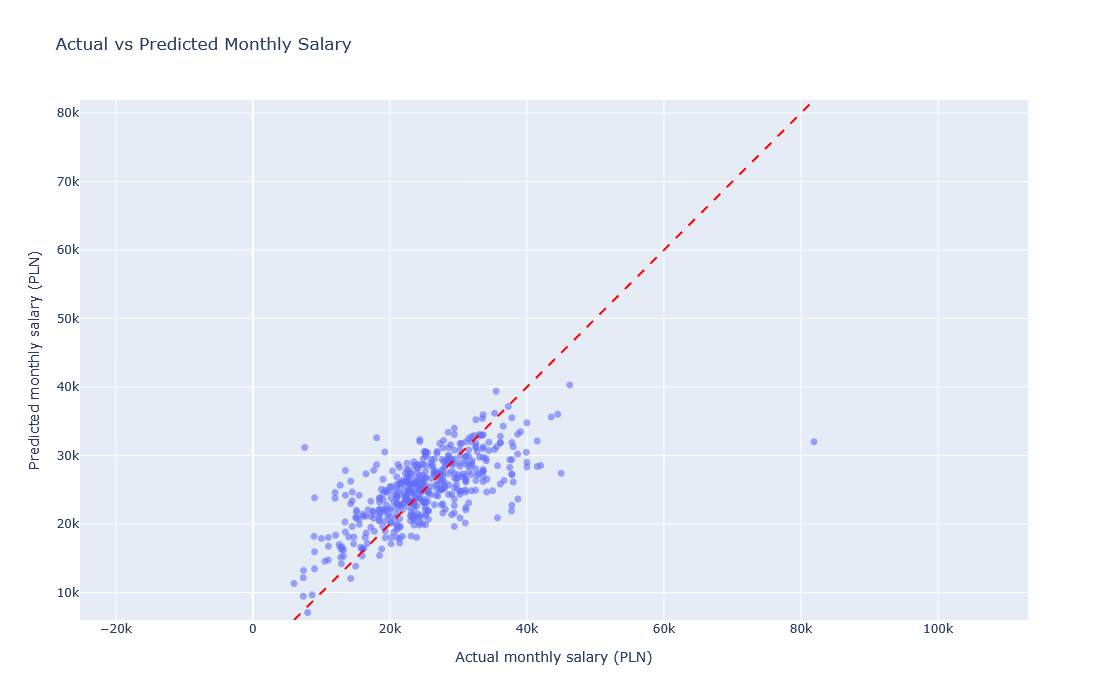

In [17]:
salary_min = min(
    prediction_results["actual_salary"].min(),
    prediction_results["predicted_salary"].min(),
)
salary_max = max(
    prediction_results["actual_salary"].max(),
    prediction_results["predicted_salary"].max(),
)

fig = px.scatter(
    prediction_results,
    x="actual_salary",
    y="predicted_salary",
    hover_data=["title", "experience", "category"],
    title="Actual vs Predicted Monthly Salary",
    labels={
        "actual_salary": "Actual monthly salary (PLN)",
        "predicted_salary": "Predicted monthly salary (PLN)",
    },
    opacity=0.6,
)
fig.add_shape(
    type="line",
    x0=salary_min,
    y0=salary_min,
    x1=salary_max,
    y1=salary_max,
    line={"color": "red", "dash": "dash", "width": 2},
)
fig.update_traces(marker={"size": 7})
fig.update_layout(
    width=850,
    height=700,
    xaxis={"range": [salary_min, salary_max]},
    yaxis={
        "range": [salary_min, salary_max],
        "scaleanchor": "x",
        "scaleratio": 1,
    },
)
fig.show()

In [18]:
largest_errors = prediction_results.nlargest(15, "absolute_error")
largest_errors[
    [
        "title", "experience", "category", "contract_type", "workplace",
        "job_locations", "actual_salary", "predicted_salary", "residual",
        "absolute_error",
    ]
].round(2)

,title,experience,category,contract_type,workplace,job_locations,actual_salary,predicted_salary,residual,absolute_error
1325,Lead Program Manager – Agentic AI Telecom Plat...,Expert,Project Manager,B2B,NaN,Missing,81900.00,32028.960938,49871.04,49871.04
186,Automation Test Lead – Data & Platform Enginee...,Senior,Testing,B2B,Remote,Remote,7560.00,31182.000000,-23622.00,23622.00
969,Golang | Go Developer | Python | Cloud | IoT |...,Senior,Backend,B2B,Hybrid,Kraków,45000.00,27420.009766,17579.99,17579.99
1461,MLOps Platform Technical Owner,Junior,AI,B2B,Remote,Remote,37750.00,21923.259766,15826.74,15826.74
983,Guidewire Developer,Mid,Backend,B2B,Hybrid,Warszawa,37800.00,22741.669922,15058.33,15058.33
2296,Senior ERP Project Manager with Dutch,Senior,Project Manager,B2B,Remote,Remote,38680.95,23644.460938,15036.49,15036.49
2004,SAP Support & Incident Manager,Mid,Project Manager,B2B,NaN,Poznań,9000.00,23825.949219,-14825.95,14825.95
540,"Data Protection Specialist (Data Discovery, CA...",Mid,Data,"B2B, Umowa o pracę",Hybrid,Kraków,35700.00,20925.000000,14775.00,14775.00
3170,Tech Lead - Data Engineering,Senior,Data,B2B,Remote,Remote,18060.00,32588.080078,-14528.08,14528.08
284,Business Development Representative – Software...,Expert,Sprzedaż,B2B,Remote,Remote,13500.00,27823.400391,-14323.39,14323.39


In [19]:
salary_bins = [5_000, 15_000, 20_000, 25_000, 30_000, 40_000, 100_000]
salary_labels = ["5–15k", "15–20k", "20–25k", "25–30k", "30–40k", "40k+"]
prediction_results["salary_band"] = pd.cut(
    prediction_results["actual_salary"],
    bins=salary_bins,
    labels=salary_labels,
    include_lowest=True,
)

error_by_salary = (
    prediction_results
    .groupby("salary_band", observed=True)
    .agg(
        job_offers=("actual_salary", "size"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
    )
    .round(2)
    .reset_index()
)
error_by_salary

,salary_band,job_offers,MAE,mean_residual
0,5–15k,43,6428.35,-6230.42
1,15–20k,60,4179.96,-3921.53
2,20–25k,145,2667.54,-1344.49
3,25–30k,108,2606.99,662.62
4,30–40k,104,5031.62,4673.48
5,40k+,8,15712.79,15712.79


The error analysis highlights regression to the mean: unusually low salaries
tend to be overestimated and unusually high salaries tend to be
underestimated. The largest errors also include offers whose titles and
structured experience labels appear inconsistent. These records are retained
because there is no deterministic basis for manually correcting source data.

## 11. Feature Importance

Permutation importance measures the increase in MAE after a raw input feature
is shuffled. It measures predictive usefulness but does not indicate whether a
feature raises or lowers predicted salary.

In [20]:
importance_result = permutation_importance(
    final_model,
    X_test_text,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=1,
)

feature_importance = (
    pd.DataFrame({
        "feature": X_test_text.columns,
        "importance": importance_result.importances_mean,
        "importance_std": importance_result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
feature_importance.head(15).round(2)

,feature,importance,importance_std
0,title,880.78,76.10
1,experience,522.01,93.80
2,experience_years_min,423.66,77.48
3,contract_type,323.31,42.71
4,category,309.99,51.77
5,job_locations,304.89,42.71
6,company_size_segment,241.55,27.95
7,skill_kubernetes,41.07,7.13
8,workplace,22.80,11.39
9,skill_python,14.35,6.55


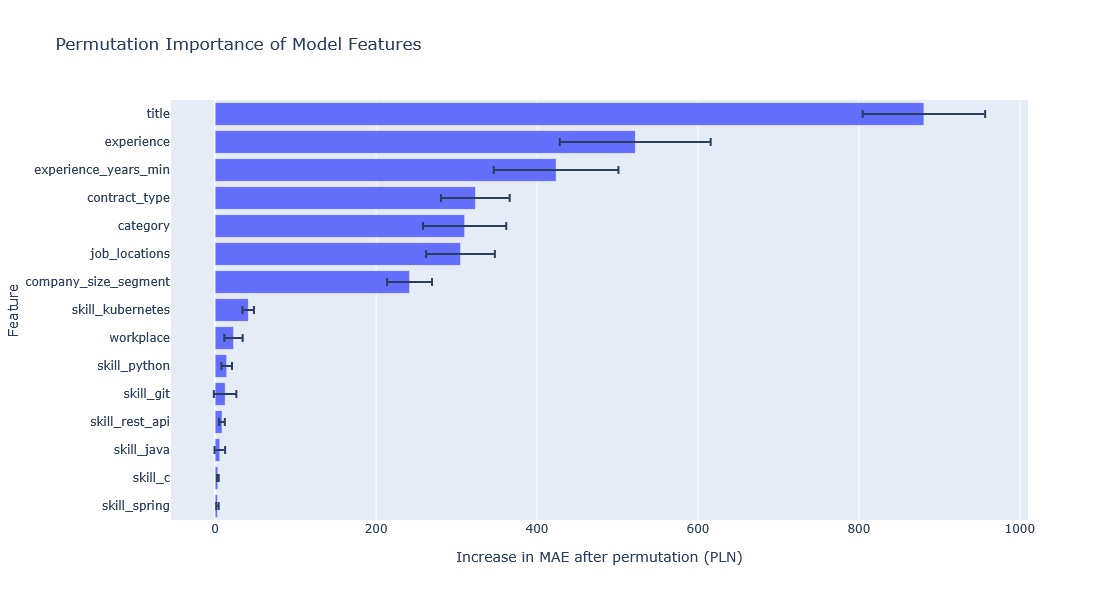

In [21]:
importance_plot = feature_importance.head(15).sort_values("importance")
fig = px.bar(
    importance_plot,
    x="importance",
    y="feature",
    orientation="h",
    error_x="importance_std",
    title="Permutation Importance of Model Features",
    labels={
        "importance": "Increase in MAE after permutation (PLN)",
        "feature": "Feature",
    },
)
fig.update_layout(width=900, height=600, showlegend=False)
fig.show()

## 12. Conclusions and Limitations

In [22]:
best_cv_mae = -xgb_text_search.best_score_
top_features = ", ".join(feature_importance.head(4)["feature"])

display(Markdown(f''' 
### Conclusions

- XGBoost achieved the strongest cross-validated performance among the tested
  algorithms.
- The tuned model reached a cross-validated MAE of approximately
  **PLN {best_cv_mae:,.0f}**.
- On the held-out test set, the final model achieved an MAE of
  **PLN {final_mae:,.0f}**, RMSE of **PLN {final_rmse:,.0f}** and
  R² of **{final_r2:.2f}**.
- The average absolute error represents **{relative_mae:.1f}%** of the median
  test-set salary.
- The most useful raw features were: **{top_features}**.
- Technology indicators contributed limited additional information, while job
  title features improved cross-validation performance and stability.
'''))

 
### Conclusions

- XGBoost achieved the strongest cross-validated performance among the tested
  algorithms.
- The tuned model reached a cross-validated MAE of approximately
  **PLN 3,896**.
- On the held-out test set, the final model achieved an MAE of
  **PLN 3,941**, RMSE of **PLN 5,548** and
  R² of **0.47**.
- The average absolute error represents **16.0%** of the median
  test-set salary.
- The most useful raw features were: **title, experience, experience_years_min, contract_type**.
- Technology indicators contributed limited additional information, while job
  title features improved cross-validation performance and stability.


### Limitations

- The data comes from one job portal and represents a cross-sectional market
  snapshot rather than a time series.
- Only offers with disclosed, normalizable and plausible salary ranges can be
  used for regression, so the modeling sample may not represent all offers.
- B2B and employment-contract amounts are not economically equivalent because
  taxation, benefits and paid leave differ.
- Employer-provided categories and experience labels can be incomplete or
  inconsistent with job titles.
- Important determinants such as client industry, detailed responsibilities,
  benefits and negotiation conditions are not fully represented.
- The model identifies associations and should not be interpreted causally or
  as an estimate of an individual candidate's market value.